In [1]:

from google.colab import files
files.upload()
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

Saving kaggle.json to kaggle.json


In [2]:
!kaggle datasets download -d laotse/credit-risk-dataset
!unzip credit-risk-dataset.zip
!ls

Dataset URL: https://www.kaggle.com/datasets/laotse/credit-risk-dataset
License(s): CC0-1.0
100% 368k/368k [00:00<00:00, 79.8MB/s]

Archive:  credit-risk-dataset.zip
  inflating: credit_risk_dataset.csv  
credit_risk_dataset.csv  credit-risk-dataset.zip  kaggle.json  sample_data


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report, roc_auc_score, roc_curve, accuracy_score
from sklearn.impute import SimpleImputer
import warnings
warnings.filterwarnings('ignore')

In [4]:
df = pd.read_csv('credit_risk_dataset.csv')

In [10]:
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


Preprocessing

 Data Cleaning
 (A) Missing Values

In [5]:
print("Missing Values:\n", df.isnull().sum())

Missing Values:
 person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64


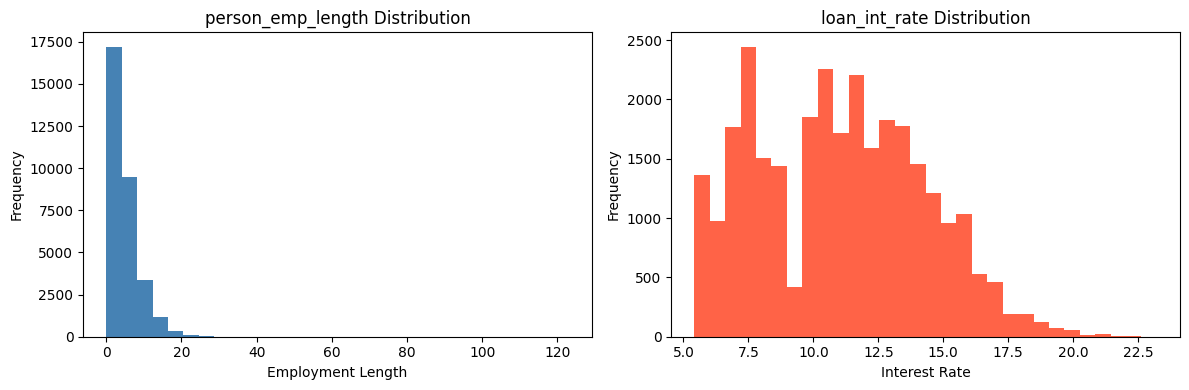

person_emp_length stats:
count    31686.000000
mean         4.789686
std          4.142630
min          0.000000
25%          2.000000
50%          4.000000
75%          7.000000
max        123.000000
Name: person_emp_length, dtype: float64

 loan_int_rate stats:
count    29465.000000
mean        11.011695
std          3.240459
min          5.420000
25%          7.900000
50%         10.990000
75%         13.470000
max         23.220000
Name: loan_int_rate, dtype: float64


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
# person_emp_length distribution
df['person_emp_length'].dropna().plot(kind='hist', bins=30, ax=axes[0], color='steelblue')
axes[0].set_title('person_emp_length Distribution')
axes[0].set_xlabel('Employment Length')
# loan_int_rate distribution
df['loan_int_rate'].dropna().plot(kind='hist', bins=30, ax=axes[1], color='tomato')
axes[1].set_title('loan_int_rate Distribution')
axes[1].set_xlabel('Interest Rate')
plt.tight_layout()
plt.show()
# Stats bhi dekhte hain
print("person_emp_length stats:")
print(df['person_emp_length'].describe())
print("\n loan_int_rate stats:")
print(df['loan_int_rate'].describe())

In [8]:
X = df.drop('loan_status', axis=1)   # Input features
y = df['loan_status']                  # Target variable
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (32581, 11)
y shape: (32581,)


In [11]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
cat_cols = X.select_dtypes(include='object').columns.tolist()
print("Categorical columns:", cat_cols)

for col in cat_cols:
    X[col] = le.fit_transform(X[col].astype(str))
    print(f"Encoded: {col}")

Categorical columns: ['person_home_ownership', 'loan_intent', 'loan_grade', 'cb_person_default_on_file']
Encoded: person_home_ownership
Encoded: loan_intent
Encoded: loan_grade
Encoded: cb_person_default_on_file


In [12]:
imputer = SimpleImputer(strategy='median')
X_imputed = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)
print("Remaining nulls:", X_imputed.isnull().sum().sum())

Remaining nulls: 0


In [15]:
X_imputed.isnull().sum()

,0
person_age,0
person_income,0
person_home_ownership,0
person_emp_length,0
loan_intent,0
loan_grade,0
loan_amnt,0
loan_int_rate,0
loan_percent_income,0
cb_person_default_on_file,0


Remove Duplicates

In [20]:
duplicates = X_imputed.duplicated().sum()
duplicates

np.int64(165)

In [22]:
len(X_imputed)

32581

In [23]:
X_imputed = X_imputed.drop_duplicates().reset_index(drop=True)
y = y[X_imputed.index] if len(y) != len(X_imputed) else y.reset_index(drop=True)

In [24]:
len(X_imputed)

32416

Wrong Data Types Fix

In [25]:
print(X_imputed.dtypes)

person_age                    float64
person_income                 float64
person_home_ownership         float64
person_emp_length             float64
loan_intent                   float64
loan_grade                    float64
loan_amnt                     float64
loan_int_rate                 float64
loan_percent_income           float64
cb_person_default_on_file     float64
cb_person_cred_hist_length    float64
dtype: object


Outliers

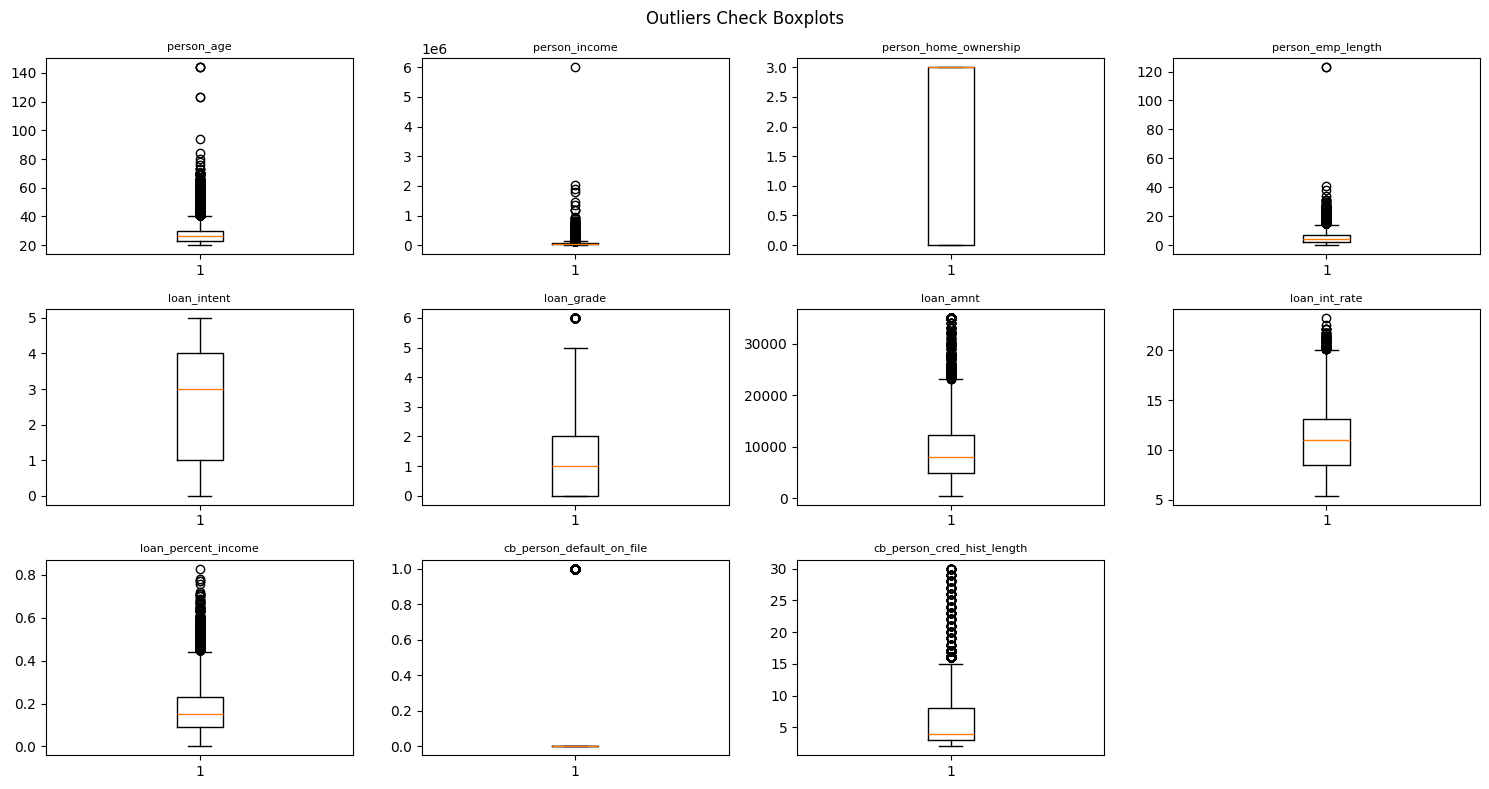

In [26]:
plt.figure(figsize=(15, 8))

for i, col in enumerate(X_imputed.select_dtypes(include='number').columns):
    plt.subplot(3, 4, i+1)
    plt.boxplot(X_imputed[col])
    plt.title(col, fontsize=8)

plt.suptitle('Outliers Check Boxplots', fontsize=12)
plt.tight_layout()
plt.show()

IQR Method for Clipping

In [27]:
columns_to_clip = [
    'person_age',
    'person_income',
    'person_emp_length',
    'loan_amnt',
    'loan_int_rate',
    'loan_percent_income',
    'cb_person_cred_hist_length'
]

for col in columns_to_clip:
    Q1 = X_imputed[col].quantile(0.25)
    Q3 = X_imputed[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    before = ((X_imputed[col] < lower) | (X_imputed[col] > upper)).sum()
    X_imputed[col] = X_imputed[col].clip(lower, upper)

    print(f" {col}: {before} outliers clipped | Range: [{lower:.2f} → {upper:.2f}]")


 person_age: 1491 outliers clipped | Range: [12.50 → 40.50]
 person_income: 1478 outliers clipped | Range: [-22472.00 → 140232.00]
 person_emp_length: 852 outliers clipped | Range: [-5.50 → 14.50]
 loan_amnt: 1679 outliers clipped | Range: [-5875.00 → 23125.00]
 loan_int_rate: 70 outliers clipped | Range: [1.56 → 20.04]
 loan_percent_income: 650 outliers clipped | Range: [-0.12 → 0.44]
 cb_person_cred_hist_length: 1139 outliers clipped | Range: [-4.50 → 15.50]


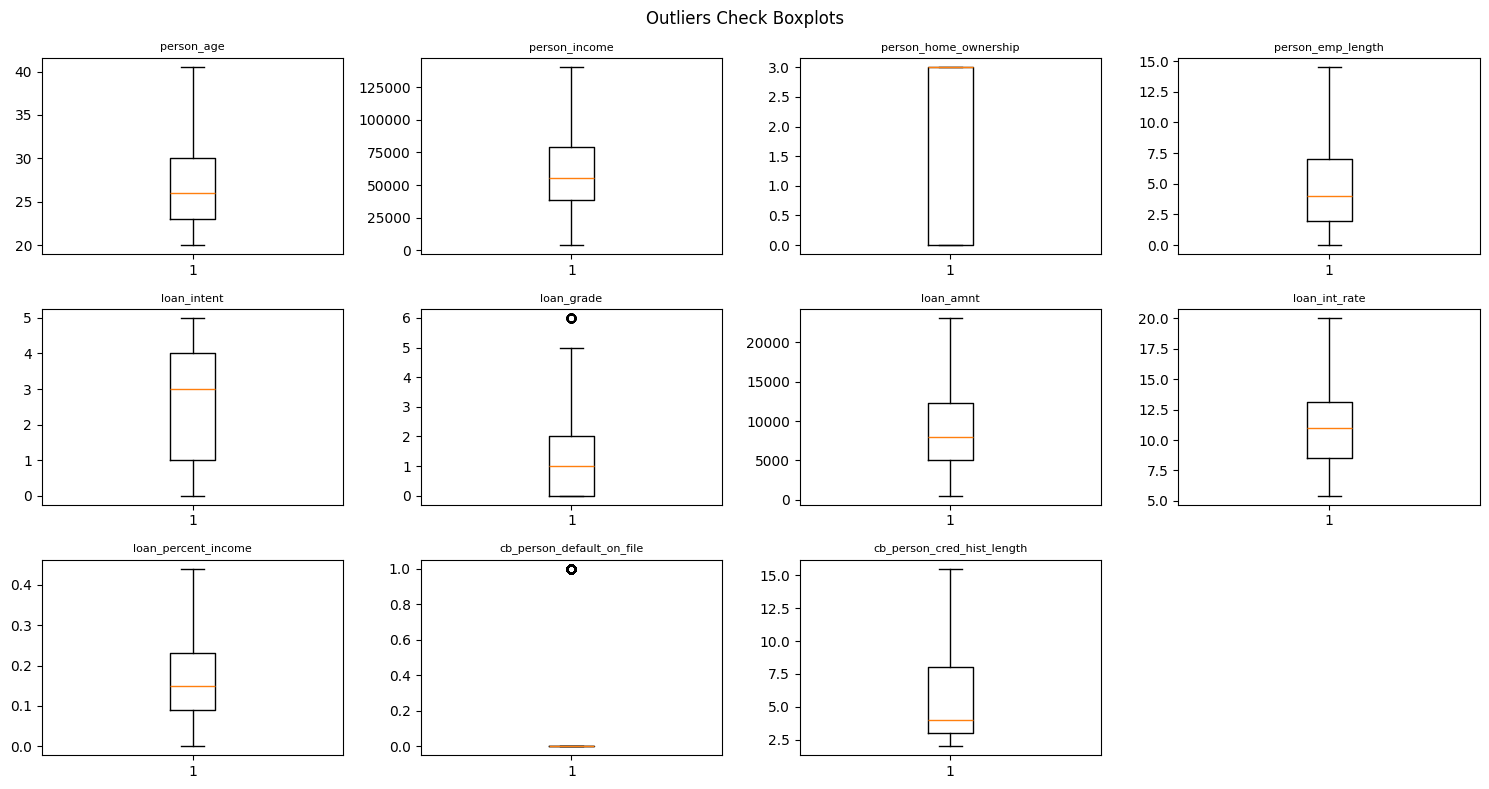

In [28]:
plt.figure(figsize=(15, 8))

for i, col in enumerate(X_imputed.select_dtypes(include='number').columns):
    plt.subplot(3, 4, i+1)
    plt.boxplot(X_imputed[col])
    plt.title(col, fontsize=8)

plt.suptitle('Outliers Check Boxplots', fontsize=12)
plt.tight_layout()
plt.show()

Exploratory Data Analysis (EDA)

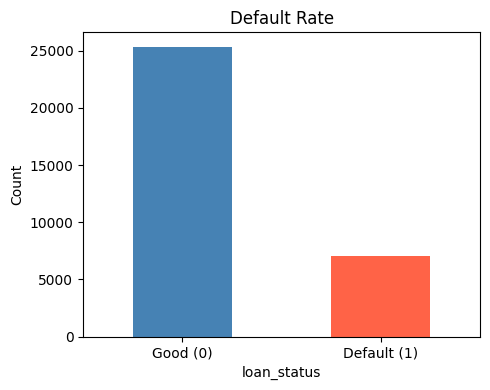

Default Rate: 21.83%


In [29]:
plt.figure(figsize=(5,4))
y.value_counts().plot(kind='bar', color=['steelblue','tomato'])
plt.title('Default Rate')
plt.xticks([0,1], ['Good (0)', 'Default (1)'], rotation=0)
plt.ylabel('Count')
plt.tight_layout()
plt.show()

print(f"Default Rate: {y.mean()*100:.2f}%")

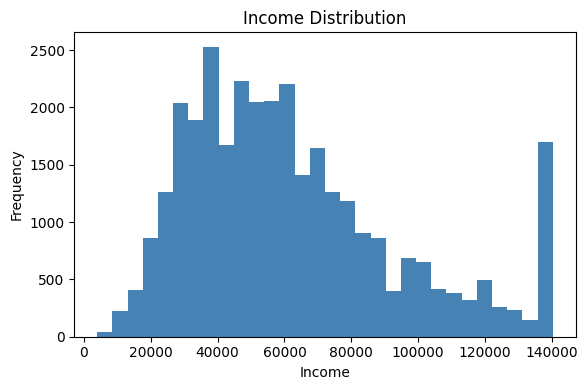

Average Income: 62437
Median Income : 55000


In [30]:
plt.figure(figsize=(6,4))
X_imputed['person_income'].plot(kind='hist', bins=30, color='steelblue')
plt.title('Income Distribution')
plt.xlabel('Income')
plt.tight_layout()
plt.show()

print(f"Average Income: {X_imputed['person_income'].mean():.0f}")
print(f"Median Income : {X_imputed['person_income'].median():.0f}")

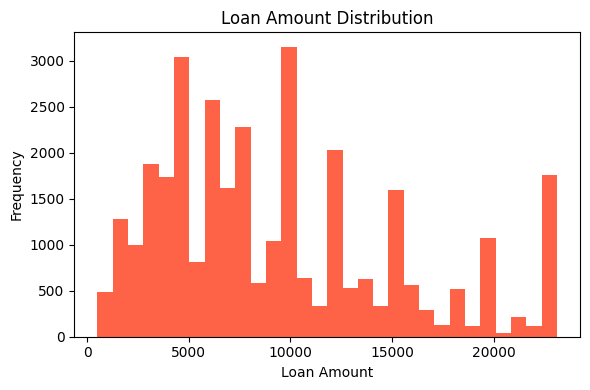

Average Loan: 9418
Max Loan    : 23125


In [31]:
plt.figure(figsize=(6,4))
X_imputed['loan_amnt'].plot(kind='hist', bins=30, color='tomato')
plt.title('Loan Amount Distribution')
plt.xlabel('Loan Amount')
plt.tight_layout()
plt.show()

print(f"Average Loan: {X_imputed['loan_amnt'].mean():.0f}")
print(f"Max Loan    : {X_imputed['loan_amnt'].max():.0f}")

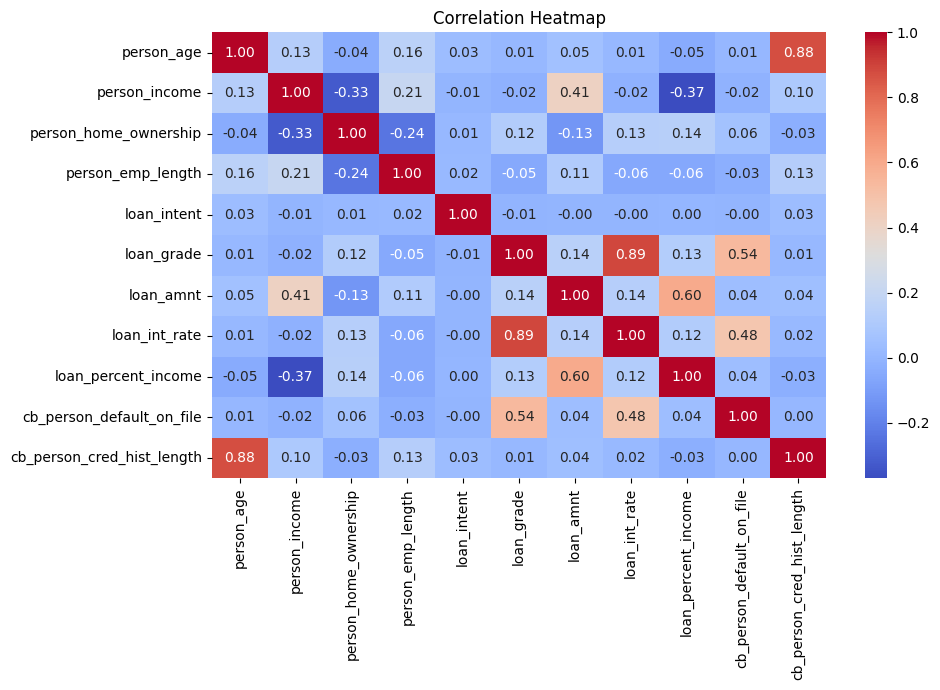

In [32]:

plt.figure(figsize=(10,7))
sns.heatmap(X_imputed.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

FEATURE ENGINEERING

In [34]:
X_imputed['loan_to_income'] = X_imputed['loan_amnt'] / (X_imputed['person_income'] + 1)
X_imputed['income_per_age'] = X_imputed['person_income'] / (X_imputed['person_age'] + 1)
print(X_imputed[['loan_to_income', 'income_per_age']].head())

   loan_to_income  income_per_age
0        0.391943     2565.217391
1        0.104156      436.363636
2        0.572857      369.230769
3        0.353048     2729.166667
4        0.425084     2176.000000


In [36]:
X_imputed

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,loan_to_income,income_per_age
0,22.0,59000.0,3.0,14.5,4.0,3.0,23125.0,16.02,0.44,1.0,3.0,0.391943,2565.217391
1,21.0,9600.0,2.0,5.0,1.0,1.0,1000.0,11.14,0.10,0.0,2.0,0.104156,436.363636
2,25.0,9600.0,0.0,1.0,3.0,2.0,5500.0,12.87,0.44,0.0,3.0,0.572857,369.230769
3,23.0,65500.0,3.0,4.0,3.0,2.0,23125.0,15.23,0.44,0.0,2.0,0.353048,2729.166667
4,24.0,54400.0,3.0,8.0,3.0,2.0,23125.0,14.27,0.44,1.0,4.0,0.425084,2176.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
32411,40.5,53000.0,0.0,1.0,4.0,2.0,5800.0,13.16,0.11,0.0,15.5,0.109432,1277.108434
32412,40.5,120000.0,0.0,4.0,4.0,0.0,17625.0,7.49,0.15,0.0,15.5,0.146874,2891.566265
32413,40.5,76000.0,3.0,3.0,2.0,1.0,23125.0,10.99,0.44,0.0,15.5,0.304272,1831.325301
32414,40.5,140232.0,0.0,5.0,4.0,1.0,15000.0,11.48,0.10,0.0,15.5,0.106965,3379.084337


Train Test Split

In [37]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_imputed, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [38]:
X_train.describe()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,loan_to_income,income_per_age
count,25932.000000,25932.000000,25932.000000,25932.000000,25932.000000,25932.000000,25932.000000,25932.000000,25932.000000,25932.000000,25932.000000,25932.000000,25932.000000
mean,27.430511,62311.045234,1.682863,4.665741,2.535979,1.218996,9420.074618,11.015182,0.169390,0.177271,5.699387,0.170699,2231.223402
std,5.261062,31818.765697,1.431638,3.713682,1.732390,1.167499,5809.617559,3.076461,0.102462,0.381906,3.699051,0.104438,1141.585842
min,20.000000,4000.000000,0.000000,0.000000,0.000000,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000,0.007131,96.385542
25%,23.000000,38400.000000,0.000000,2.000000,1.000000,0.000000,5000.000000,8.490000,0.090000,0.000000,3.000000,0.092151,1366.517857
50%,26.000000,55000.000000,3.000000,4.000000,3.000000,1.000000,8000.000000,10.990000,0.150000,0.000000,4.000000,0.149999,2000.000000
75%,30.000000,78996.000000,3.000000,7.000000,4.000000,2.000000,12125.000000,13.110000,0.230000,0.000000,8.000000,0.227266,2875.000000
max,40.500000,140232.000000,3.000000,14.500000,5.000000,6.000000,23125.000000,20.040000,0.440000,1.000000,15.500000,0.829959,6677.714286


Scaling

In [39]:
from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()

X_train_sc = scaler.fit_transform(X_train)   # fit + transform
X_test_sc  = scaler.transform(X_test)

SMOTE (Class Imbalance fix)

In [48]:
!pip install imbalanced-learn -q

from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train_sc, y_train)

In [50]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report, roc_auc_score, accuracy_score

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42)
}

results = {}

for name, model in models.items():
    model.fit(X_train_sm, y_train_sm)
    y_pred = model.predict(X_test_sc)
    y_prob = model.predict_proba(X_test_sc)[:, 1]
    acc = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)
    results[name] = {'model': model, 'auc': auc, 'acc': acc, 'y_prob': y_prob}
    print(f"\n {name} ")
    print(f"Accuracy : {acc:.4f}")
    print(f"AUC-ROC  : {auc:.4f}")
    print(classification_report(y_test, y_pred))


 Logistic Regression 
Accuracy : 0.6519
AUC-ROC  : 0.6858
              precision    recall  f1-score   support

           0       0.86      0.67      0.75      5068
           1       0.33      0.60      0.43      1416

    accuracy                           0.65      6484
   macro avg       0.60      0.63      0.59      6484
weighted avg       0.74      0.65      0.68      6484


 Random Forest 
Accuracy : 0.8310
AUC-ROC  : 0.7589
              precision    recall  f1-score   support

           0       0.85      0.95      0.90      5068
           1       0.70      0.39      0.50      1416

    accuracy                           0.83      6484
   macro avg       0.78      0.67      0.70      6484
weighted avg       0.82      0.83      0.81      6484


 Gradient Boosting 
Accuracy : 0.8328
AUC-ROC  : 0.7549
              precision    recall  f1-score   support

           0       0.85      0.96      0.90      5068
           1       0.72      0.39      0.50      1416

    accuracy 

ROC-CURVE

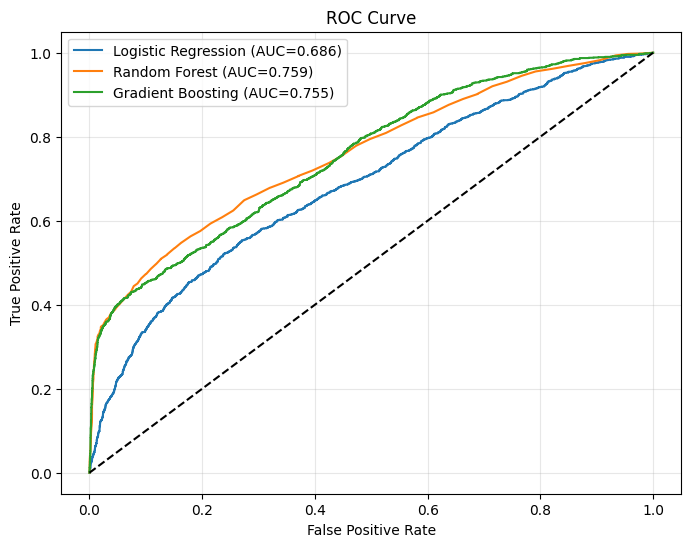

In [51]:

from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
for name, res in results.items():
    fpr, tpr, _ = roc_curve(y_test, res['y_prob'])
    plt.plot(fpr, tpr, label=f"{name} (AUC={res['auc']:.3f})")

plt.plot([0,1],[0,1],'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [52]:
import joblib
from google.colab import drive

drive.mount('/content/drive')

joblib.dump(results['Random Forest']['model'], '/content/drive/MyDrive/Trained Saved Models/CreditScoringModel/credit_scoring_model.pkl')
joblib.dump(scaler, '/content/drive/MyDrive/Trained Saved Models/CreditScoringModel/scaler.pkl')

Mounted at /content/drive


['/content/drive/MyDrive/Trained Saved Models/CreditScoringModel/scaler.pkl']